In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. Load Data from Source ---
print("Downloading Boston Housing Dataset...")
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# The dataset is formatted with data split across lines, so we reshape it
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Feature Names
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

# Create DataFrame
df = pd.DataFrame(data, columns=feature_names)
df['MEDV'] = target

# --- 2. Select Specific Features ---
# Requirement: Predict 'MEDV' using 'RM' and 'CRIM' [cite: 24-26]
X = df[['RM', 'CRIM']].values
y = df['MEDV'].values.reshape(-1, 1)

# --- 3. Preprocessing ---
# Requirement: Normalize features
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Requirement: Split 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

print("Data Loaded Successfully.")
print(f"Features: {['RM', 'CRIM']}")
print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-4244013753.py:10: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


Data Loaded Successfully.
Features: ['RM', 'CRIM']
Training Samples: 404
Testing Samples: 102


In [2]:
import numpy as np

class NeuralNetwork_Regression:
    def __init__(self, input_size=2, learning_rate=0.01, optimizer="gd"):
        # Architecture defined in assignment [cite: 38-45]
        # Layer 1: Input (2) -> Hidden (5)
        # Layer 2: Hidden (5) -> Hidden (3)
        # Layer 3: Hidden (3) -> Output (1)

        self.input_size = input_size
        self.hidden1_size = 5
        self.hidden2_size = 3
        self.output_size = 1
        self.lr = learning_rate
        self.optimizer = optimizer

        # Initialize Weights (He Initialization for ReLU)
        np.random.seed(42)
        self.W1 = np.random.randn(self.input_size, self.hidden1_size) * np.sqrt(2/self.input_size)
        self.b1 = np.zeros((1, self.hidden1_size))

        self.W2 = np.random.randn(self.hidden1_size, self.hidden2_size) * np.sqrt(2/self.hidden1_size)
        self.b2 = np.zeros((1, self.hidden2_size))

        self.W3 = np.random.randn(self.hidden2_size, self.output_size) * np.sqrt(2/self.hidden2_size)
        self.b3 = np.zeros((1, self.output_size))

        # Optimizer State Variables (for Momentum/Adam)
        self.vW1, self.vb1 = 0, 0
        self.vW2, self.vb2 = 0, 0
        self.vW3, self.vb3 = 0, 0

        # Adam specific (Second moments)
        self.mW1, self.mb1 = 0, 0
        self.mW2, self.mb2 = 0, 0
        self.mW3, self.mb3 = 0, 0
        self.t = 0 # Time step

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def forward(self, X):
        # Layer 1
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1)

        # Layer 2
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.relu(self.z2)

        # Output Layer (Linear Activation for Regression)
        self.z3 = np.dot(self.a2, self.W3) + self.b3
        self.output = self.z3
        return self.output

    def backward(self, X, y):
        m = X.shape[0]

        # 1. Output Layer Gradients
        # Loss = 0.5(y_pred - y)^2  -> dLoss/dPred = (y_pred - y)
        delta3 = self.output - y
        dW3 = np.dot(self.a2.T, delta3) / m
        db3 = np.sum(delta3, axis=0, keepdims=True) / m

        # 2. Hidden Layer 2 Gradients
        delta2 = np.dot(delta3, self.W3.T) * self.relu_derivative(self.z2)
        dW2 = np.dot(self.a1.T, delta2) / m
        db2 = np.sum(delta2, axis=0, keepdims=True) / m

        # 3. Hidden Layer 1 Gradients
        delta1 = np.dot(delta2, self.W2.T) * self.relu_derivative(self.z1)
        dW1 = np.dot(X.T, delta1) / m
        db1 = np.sum(delta1, axis=0, keepdims=True) / m

        self.update_weights([dW1, dW2, dW3], [db1, db2, db3])

    def update_weights(self, dWs, dbs):
        dW1, dW2, dW3 = dWs
        db1, db2, db3 = dbs

        # --- OPTIMIZER LOGIC ---

        if self.optimizer == "gd":
            # Vanilla Gradient Descent
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
            self.W3 -= self.lr * dW3
            self.b3 -= self.lr * db3

        elif self.optimizer == "momentum":
            # Momentum (gamma = 0.9)
            gamma = 0.9

            self.vW1 = gamma * self.vW1 + self.lr * dW1
            self.W1 -= self.vW1

            self.vW2 = gamma * self.vW2 + self.lr * dW2
            self.W2 -= self.vW2

            self.vW3 = gamma * self.vW3 + self.lr * dW3
            self.W3 -= self.vW3

            # (Update biases similarly...)
            self.vb1 = gamma * self.vb1 + self.lr * db1
            self.b1 -= self.vb1
            self.vb2 = gamma * self.vb2 + self.lr * db2
            self.b2 -= self.vb2
            self.vb3 = gamma * self.vb3 + self.lr * db3
            self.b3 -= self.vb3

        elif self.optimizer == "adam":
            # Adam (beta1=0.9, beta2=0.999, eps=1e-8)
            beta1, beta2, eps = 0.9, 0.999, 1e-8
            self.t += 1

            # Helper for Adam update
            def apply_adam(param, grad, m, v, t):
                m = beta1 * m + (1 - beta1) * grad
                v = beta2 * v + (1 - beta2) * (grad**2)
                m_hat = m / (1 - beta1**t)
                v_hat = v / (1 - beta2**t)
                param -= self.lr * m_hat / (np.sqrt(v_hat) + eps)
                return param, m, v

            self.W1, self.mW1, self.vW1 = apply_adam(self.W1, dW1, self.mW1, self.vW1, self.t)
            self.W2, self.mW2, self.vW2 = apply_adam(self.W2, dW2, self.mW2, self.vW2, self.t)
            self.W3, self.mW3, self.vW3 = apply_adam(self.W3, dW3, self.mW3, self.vW3, self.t)

            self.b1, self.mb1, self.vb1 = apply_adam(self.b1, db1, self.mb1, self.vb1, self.t)
            self.b2, self.mb2, self.vb2 = apply_adam(self.b2, db2, self.mb2, self.vb2, self.t)
            self.b3, self.mb3, self.vb3 = apply_adam(self.b3, db3, self.mb3, self.vb3, self.t)

    def train(self, X, y, epochs=1000):
        loss_history = []
        for i in range(epochs):
            # Forward
            y_pred = self.forward(X)

            # Loss (MSE)
            loss = np.mean((y_pred - y)**2)
            loss_history.append(loss)

            # Backward
            self.backward(X, y)

        return loss_history

Training with Gradient Descent...
Training with Momentum...
Training with Adam...


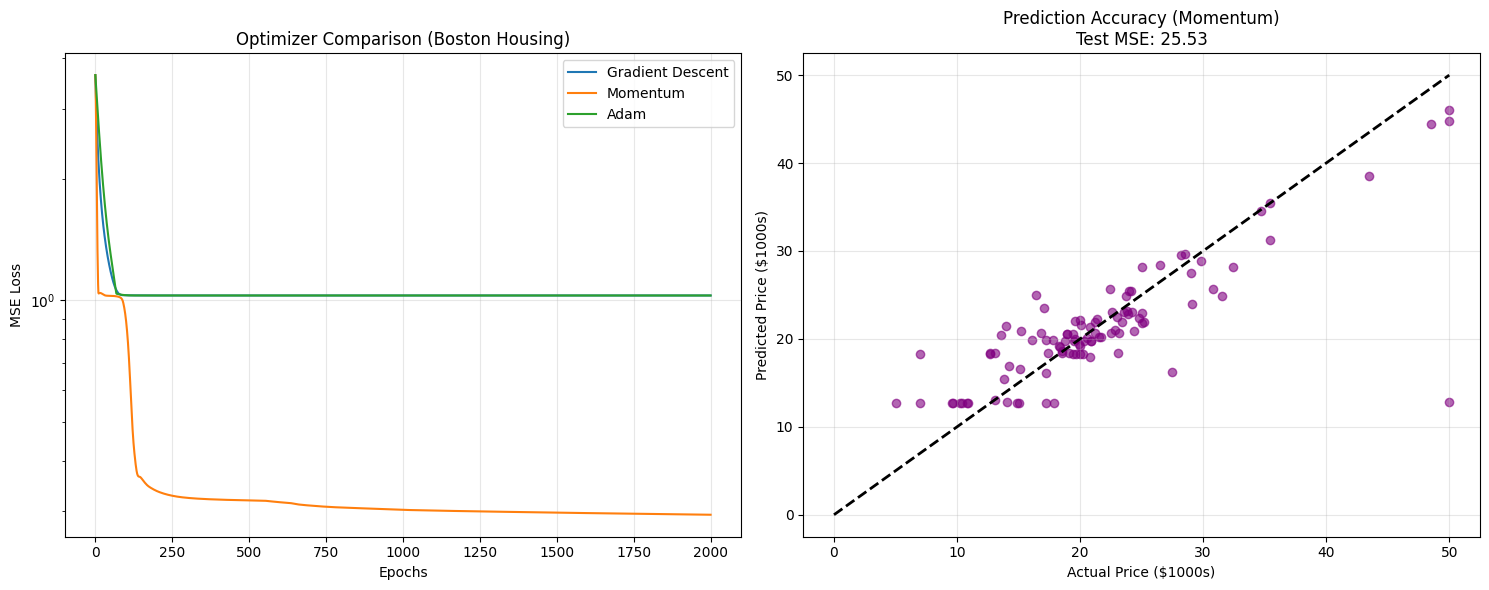


--- Final Test Set MSE (Normalized) ---
Gradient Descent: 0.88892
Momentum: 0.30246
Adam: 0.88896


In [9]:
# --- Configuration ---
epochs = 2000 # Enough to see convergence
learning_rate = 0.01

# --- 1. Train Models with Different Optimizers ---
results = {}
models = {}

print("Training with Gradient Descent...")
model_gd = NeuralNetwork_Regression(input_size=2, learning_rate=learning_rate, optimizer="gd")
results["Gradient Descent"] = model_gd.train(X_train, y_train, epochs)
models["Gradient Descent"] = model_gd

print("Training with Momentum...")
model_mom = NeuralNetwork_Regression(input_size=2, learning_rate=learning_rate, optimizer="momentum")
results["Momentum"] = model_mom.train(X_train, y_train, epochs)
models["Momentum"] = model_mom

print("Training with Adam...")
model_adam = NeuralNetwork_Regression(input_size=2, learning_rate=0.005, optimizer="adam") # Adam often needs lower LR
results["Adam"] = model_adam.train(X_train, y_train, epochs)
models["Adam"] = model_adam

# --- 2. Visualization ---
plt.figure(figsize=(15, 6))

# Plot A: Convergence (Loss vs Epochs)
plt.subplot(1, 2, 1)
for name, loss_hist in results.items():
    plt.plot(loss_hist, label=name)
plt.title("Optimizer Comparison (Boston Housing)")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.yscale('log') # Log scale helps see the difference better
plt.grid(True, alpha=0.3)

# Plot B: Predicted vs Actual (Test Set Evaluation)
# We use the best model (usually Adam) for this plot
best_model = models["Momentum"]
y_pred_test = best_model.forward(X_test)

# Inverse transform to get real prices (in $1000s) instead of normalized values
y_test_real = scaler_y.inverse_transform(y_test)
y_pred_real = scaler_y.inverse_transform(y_pred_test)

plt.subplot(1, 2, 2)
plt.scatter(y_test_real, y_pred_real, alpha=0.6, color='purple')
plt.plot([0, 50], [0, 50], 'k--', lw=2) # Perfect prediction line
plt.title(f"Prediction Accuracy (Momentum)\nTest MSE: {np.mean((y_test_real - y_pred_real)**2):.2f}")
plt.xlabel("Actual Price ($1000s)")
plt.ylabel("Predicted Price ($1000s)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 3. Final Metrics ---
print("\n--- Final Test Set MSE (Normalized) ---")
for name, model in models.items():
    test_pred = model.forward(X_test)
    mse = np.mean((test_pred - y_test)**2)
    print(f"{name}: {mse:.5f}")

Starting Multi-LR Experiments on Boston Housing Data...
Testing LRs: [0.1, 0.01, 0.001]

--- Testing Learning Rate: 0.1 ---
  gd: Final MSE = 1.0291 (Converged)
  momentum: Final MSE = 0.2821 (Converged)
  adam: Final MSE = 0.2668 (Converged)

--- Testing Learning Rate: 0.01 ---
  gd: Final MSE = 1.0291 (Converged)
  momentum: Final MSE = 0.3017 (Converged)
  adam: Final MSE = 1.0291 (Converged)

--- Testing Learning Rate: 0.001 ---
  gd: Final MSE = 1.0302 (Converged)
  momentum: Final MSE = 1.0291 (Converged)
  adam: Final MSE = 1.0290 (Converged)


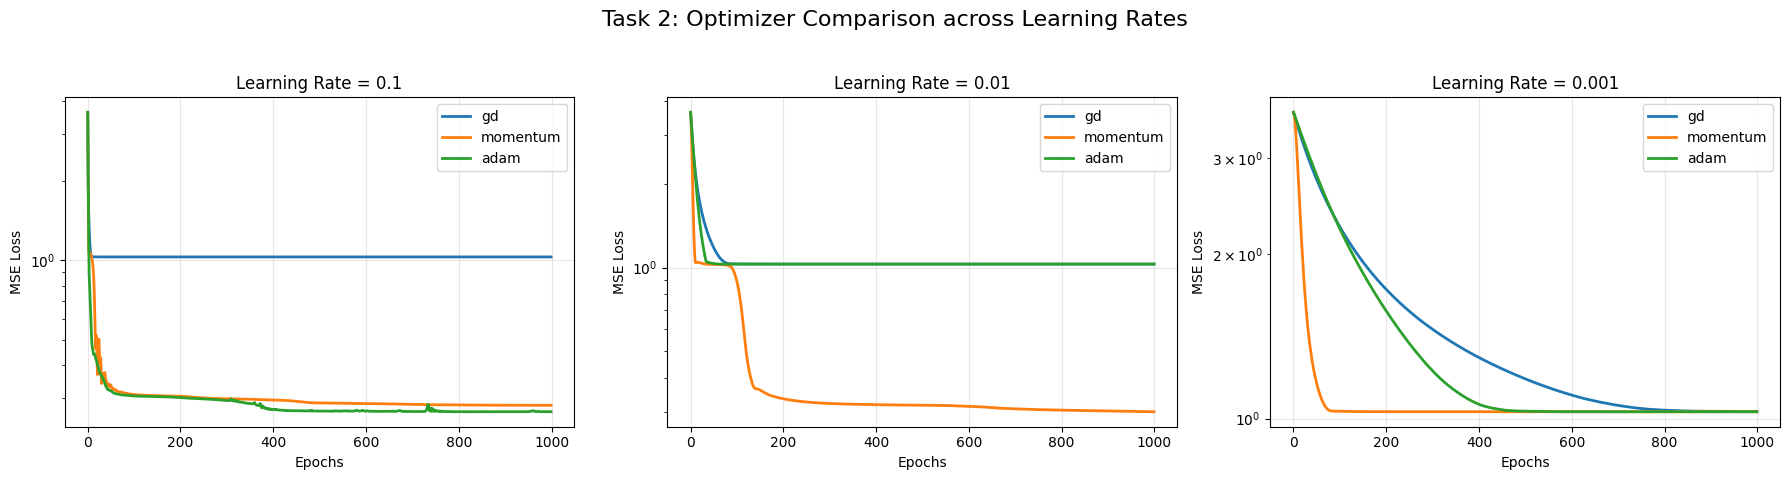


--- Visualizing Best Model Predictions (LR=0.01, Adam) ---


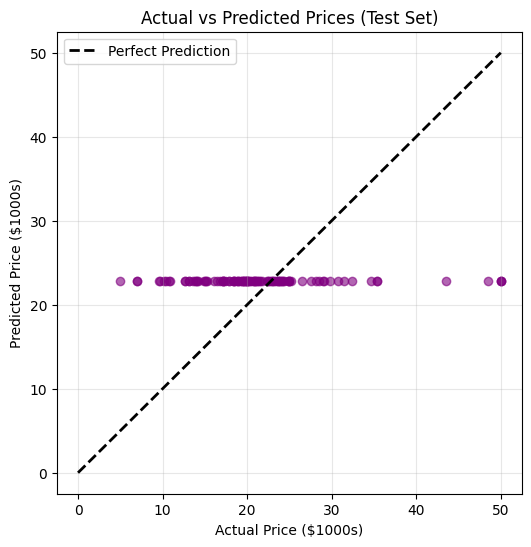

In [10]:
# --- Configuration ---
learning_rates = [0.1, 0.01, 0.001]
epochs = 1000
optimizers = ["gd", "momentum", "adam"]

# Dictionary to store results: results[lr][opt_name] = loss_history
results = {lr: {} for lr in learning_rates}

print(f"Starting Multi-LR Experiments on Boston Housing Data...")
print(f"Testing LRs: {learning_rates}")

# --- 1. Run Experiments ---
for lr in learning_rates:
    print(f"\n--- Testing Learning Rate: {lr} ---")

    for opt_name in optimizers:
        # Re-initialize model for every experiment to ensure fair start
        model = NeuralNetwork_Regression(input_size=2, learning_rate=lr, optimizer=opt_name)

        try:
            # Train
            loss_hist = model.train(X_train, y_train, epochs)
            results[lr][opt_name] = loss_hist

            final_loss = loss_hist[-1]
            status = "Converged" if final_loss < 100 else "Exploded?"
            print(f"  {opt_name}: Final MSE = {final_loss:.4f} ({status})")

        except RuntimeWarning:
            print(f"  {opt_name}: Diverged (Math Error)")
            results[lr][opt_name] = [] # Empty list indicates failure

# --- 2. Visualization (3 Subplots) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Task 2: Optimizer Comparison across Learning Rates", fontsize=16)

for i, lr in enumerate(learning_rates):
    ax = axes[i]

    for opt_name in optimizers:
        loss_data = results[lr][opt_name]

        # Safety check: if loss exploded to NaN or Infinity, don't plot the whole thing
        if len(loss_data) > 0 and not np.isnan(loss_data[-1]):
            ax.plot(loss_data, label=opt_name, linewidth=2)

    ax.set_title(f"Learning Rate = {lr}")
    ax.set_xlabel("Epochs")
    ax.set_ylabel("MSE Loss")
    ax.set_yscale('log') # Log scale is crucial for Regression loss
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 3. Best Model Evaluation ---
# We pick the best result from LR=0.01 (usually stable) to show the regression line
print("\n--- Visualizing Best Model Predictions (LR=0.01, Adam) ---")
best_model = NeuralNetwork_Regression(input_size=2, learning_rate=0.01, optimizer="adam")
best_model.train(X_train, y_train, epochs)

y_pred_test = best_model.forward(X_test)
y_test_real = scaler_y.inverse_transform(y_test)
y_pred_real = scaler_y.inverse_transform(y_pred_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.6, color='purple')
plt.plot([0, 50], [0, 50], 'k--', lw=2, label="Perfect Prediction")
plt.title("Actual vs Predicted Prices (Test Set)")
plt.xlabel("Actual Price ($1000s)")
plt.ylabel("Predicted Price ($1000s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()